# Nessie Tutorial: Tuning linking lengths

In this tutorial we show how to use the optimize_mn function in `nessie_py` to find the best fitting linking lengths r0 and b0 which can be used to run the group finder. 

Usually this is done by using a mock-catalogue with known groupings, but one isn't readily availble for SDSS so we instead use the existing catalog and assume it as "truth". We emphaisze that this workflow would works exactly the same as if there were a mock catalog.

In [1]:
# Download data

from astroquery.vizier import Vizier

columns = ["GroupID", "Ngal", "zobs", "RAJ2000", "DEJ2000", "rmag"]
vizier = Vizier(columns = columns, row_limit = -1)
sdss_galaxies = vizier.get_catalogs("J/A+A/602/A100/table1")

# These are survey properties that you need to know before hand.
SDSS_MAG_LIM = 17.77
SDSS_FRACTIONAL_AREA = 0.2126803
SDSS_MAX_REDSHIFT = 0.2

import numpy as np
catalog = sdss_galaxies[0]
df = catalog.to_pandas()
df = df[df['rmag'] < SDSS_MAG_LIM]

ra  = np.array(df['RAJ2000'])
dec = np.array(df['DEJ2000'])
mult = np.array(df['Ngal'])
redshift = np.array(df['zobs'])
mag = np.array(df['rmag'])
tempel_group_id = np.array(df['GroupID'])



Here we will assume that the tempel_group_id represents the "true" grouping. Very importantly, `Nessie` **needs the ungrouped galaxies to have the id value of -1, if it doesn't, then the tuning and comparison will not work!**  For this SDSS catalog the ungroup galaxies have an ID of 0. So this needs to be changed.

In [2]:
tempel_group_id[tempel_group_id == 0] = -1

## Setting up the redshift catalog object

Tuning the linking lengths begins in the exact same way as running the group finder normally (see the SDSS specfic tutorial for details). So here we will simply define a randoms catalog to use for the density function and set up the cosmology and assume 100% completeness. We will then pass this to a redshift catalog object.

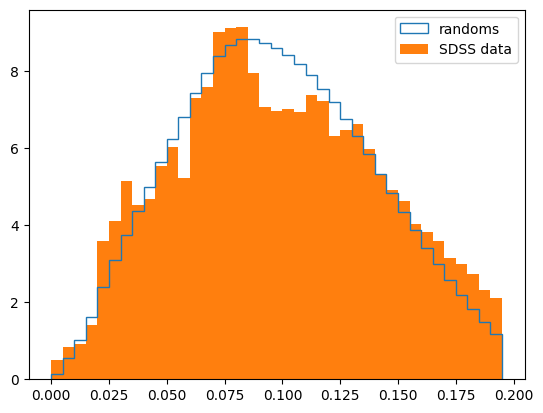

In [3]:
import pylab as plt
from nessie import FlatCosmology, RedshiftCatalog
from nessie.helper_funcs import create_density_function, gen_random_redshifts

cosmo = FlatCosmology(0.7, 0.3)
randoms = gen_random_redshifts(redshift, mag, SDSS_MAX_REDSHIFT, SDSS_MAG_LIM, cosmo, n_clone=100)

# Making sure that the randoms are mapping out the n(z) correctly.
plt.hist(randoms, bins=np.arange(0, 0.2, 0.005), density=True, histtype='step', label='randoms')
plt.hist(redshift, bins = np.arange(0, 0.2, 0.005), density=True, label='SDSS data')
plt.legend()
plt.show()

rho = create_density_function(randoms, len(redshift), SDSS_FRACTIONAL_AREA, cosmo)
red_cat = RedshiftCatalog(ra, dec, redshift, rho, cosmo)
red_cat.set_completeness() # Assuming 100% completeness


These are all the steps that would be required to run the group finder in any case. The only change now is that we need to pass the "true" group ids **with the ungrouped galaxies having a group id of -1**. The group finding can then be tuned, choosing the minimum number of members per group that should be used to tune it. Usually >=5 is recommended. (See Robotham+2011 for more details).

The optimizer available to the python version of nessie is the simple neader-meade optimization routine. This has the benefit of running quickly but the linking length priors are not well sampled meaning that there aren't uncertainties associated with them. More exhaustive parameter optimization is available in the R version of `Nessie`. However, linking lengths are quite robust, and have a wide range of acceptable choices. The Neder-Meade method should suffice most cases. 

This method will take some time on a catalog the size of SDSS.

In [4]:
from datetime import datetime
from nessie.optimizer import optimize_nm

red_cat.mock_group_ids = tempel_group_id
start = datetime.now()
b0, r0 = optimize_nm(red_cat, 5)
end = datetime.now()
print(f"Time take is: {end - start}")
print(f"Best values are: b0 = {b0} and r0 = {r0}")

Time take is: 0:06:29.678279
Best values are: b0 = 0.05934234619140624 and r0 = 23.845458984375


Thats it! You know have the linking lengths that you can use to build the group finder on the SDSS data. See the SDSS tutorial to see how. 